In [1]:
import sys, os
os.path.dirname(sys.executable)
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import graph_utils
from ESMCBA import other_utils
import importlib
importlib.reload(other_utils)
from pathlib import Path

### Load dt

In [2]:
test_datasets_df = ['A3101 HLA', 'B1402 epitope', 'A0205 epitope', 'B5101 epitope',
       'B5701 epitope', 'A3101 epitope', 'B5701 HLA', 'B1801 HLA',
       'B4403 epitope', 'A3301 HLA', 'A1101 HLA', 'B1801 epitope',
       'A1101 epitope', 'B1501 epitope', 'B4403 HLA', 'B5101 HLA',
       'A2601 HLA', 'B1501 HLA', 'B3801 epitope', 'A3001 HLA',
       'A0205 HLA', 'A2601 epitope', 'B3801 HLA', 'A6801 HLA',
       'A6801 epitope', 'A0101 HLA', 'B0702 HLA', 'A3301 epitope',
       'B5301 HLA', 'B0702 epitope', 'A0101 epitope', 'B3906 epitope',
       'C0602 HLA', 'A0301 HLA', 'A0301 epitope', 'A0201 HLA',
       'A0201 epitope', 'A3001 epitope', 'B3901 epitope', 'B4402 HLA',
       'B0801 HLA', 'B4402 epitope', 'B0801 epitope', 'B3906 HLA',
       'B3901 HLA', 'B1402 HLA', 'A2402 epitope', 'A2402 HLA',
       'B4001 epitope', 'A6802 epitope', 'B4001 HLA', 'C0701 epitope',
       'A0206 epitope', 'B3501 epitope', 'A3201 epitope', 'A3201 HLA',
       'A6802 HLA', 'A0206 HLA', 'B3501 HLA', 'C0701 HLA']

test_datasets_df = [x.split(' ')[0] for x in test_datasets_df]

In [3]:
####. The outputs are the UMAP outputs geerated with ESMCBA/

### we used embeddings_generation.py for this 


## I thought we were pulling these wait no umap ??

In [4]:
eval_base = '/global/scratch/users/sergiomar10/ESMCBA/benchmark'
mhcflurry_base = eval_base
netmhc_base = eval_base

# Storage
merged_dfs_by_HLA = {}

# test_datasets_df['allele'] = test_datasets_df['HLA']

for HLA in test_datasets_df:

    # if HLA not in 'A0201':
    #     continue

    try:
        formatted_HLA = HLA.replace("*", "").replace(":", "")
        print(f"\n🔍 Processing {HLA}")

        # Find all ESMCBA predictions for this allele
        esmc_files = glob.glob(f"{eval_base}/*epitope*{HLA}*umap*.csv") #, recursive=True)
        # esmc_files = [f for f in esmc_files if "umap" not in f and "mhc_flurry" not in f and "netmhc" not in f]
        if len(esmc_files) == 0:
            print(f"⚠️ No ESMCBA predictions found for {HLA}")
            continue

        # Load first valid ESMCBA prediction file
        for esmc_path in esmc_files:
            try:
                fine_tuned_df = pd.read_csv(esmc_path)
                if 'sequence' not in fine_tuned_df.columns:
                    continue
                break
            except Exception:
                continue
        else:
            print(f"❌ Could not read any valid ESMCBA file for {HLA}")
            continue

        merged_df = fine_tuned_df.copy()

        # MHCflurry
        mhc_path = f"{mhcflurry_base}/{formatted_HLA}_mhcflurry.csv"
        if os.path.exists(mhc_path):
            mhc_pred = pd.read_csv(mhc_path)
            if 'affinity' in mhc_pred.columns:
                mhc_pred = mhc_pred.rename(columns={'affinity': 'mhcflurry_affinity'})
            merged_df = pd.merge(merged_df, mhc_pred, left_on='sequence', right_on='peptide', how='left')
            merged_df['mhc_log'] = merged_df['mhcflurry_affinity'].replace(0, np.nan).apply(np.log10)
        else:
            print(f"⚠️ MHCflurry missing for {HLA}")

        # NetMHCpan
        netmhc_path = f"{netmhc_base}/netmhc_{formatted_HLA}.xls"
        if os.path.exists(netmhc_path):
            try:
                netmhc_df = pd.read_csv(netmhc_path, sep='\t', header=1)
                netmhc_df.columns = netmhc_df.columns.str.strip()
                if 'Peptide' in netmhc_df.columns and 'BA_Rank' in netmhc_df.columns:
                    netmhc_df['netmhc_log'] = netmhc_df['BA_Rank']#.replace(0, np.nan).apply(np.log10)
                    merged_df = pd.merge(merged_df, netmhc_df[['Peptide', 'netmhc_log']],
                                         left_on='sequence', right_on='Peptide', how='left')
            except Exception:
                print(f"❌ Could not parse NetMHCpan file for {HLA}")
        else:
            print(f"⚠️ NetMHCpan missing for {HLA}")

        # Finalize
        merged_df = merged_df.drop_duplicates('sequence')

        if len(merged_df.columns) > 12:
            merged_dfs_by_HLA[HLA] = merged_df
        # break

    except Exception as e:
        print(f"❌ Error processing {HLA}: {e}")



🔍 Processing A3101

🔍 Processing B1402
⚠️ No ESMCBA predictions found for B1402

🔍 Processing A0205
❌ Could not parse NetMHCpan file for A0205

🔍 Processing B5101

🔍 Processing B5701

🔍 Processing A3101

🔍 Processing B5701

🔍 Processing B1801

🔍 Processing B4403
⚠️ No ESMCBA predictions found for B4403

🔍 Processing A3301
❌ Could not parse NetMHCpan file for A3301

🔍 Processing A1101

🔍 Processing B1801

🔍 Processing A1101

🔍 Processing B1501

🔍 Processing B4403
⚠️ No ESMCBA predictions found for B4403

🔍 Processing B5101

🔍 Processing A2601

🔍 Processing B1501

🔍 Processing B3801

🔍 Processing A3001

🔍 Processing A0205
❌ Could not parse NetMHCpan file for A0205

🔍 Processing A2601

🔍 Processing B3801

🔍 Processing A6801

🔍 Processing A6801

🔍 Processing A0101

🔍 Processing B0702

🔍 Processing A3301
❌ Could not parse NetMHCpan file for A3301

🔍 Processing B5301

🔍 Processing B0702

🔍 Processing A0101

🔍 Processing B3906

🔍 Processing C0602

🔍 Processing A0301

🔍 Processing A0301

🔍 Pr

In [5]:
all_predictions = pd.concat(merged_dfs_by_HLA).reset_index()

In [6]:
all_predictions

,level_0,level_1,sequence,prediction,UMAP_1,UMAP_2,allele,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile,mhc_log,Peptide,netmhc_log
0,A3101,0,LVMAFIAFLR,1.716352,9.400377,9.829111,A3101,LVMAFIAFLR,47.610620,0.179625,0.014859,0.651150,0.523071,1.677704,LVMAFIAFLR,0.0655
1,A3101,1,RVQFIPGQR,1.333629,10.547241,10.252823,A3101,RVQFIPGQR,27.052885,0.026500,0.605975,0.963195,0.028207,1.432214,RVQFIPGQR,0.0791
2,A3101,2,TTIEDILPK,3.270586,4.388390,7.108198,A3101,TTIEDILPK,349.300240,0.994250,0.783229,0.803277,0.272717,2.543199,TTIEDILPK,7.2197
3,A3101,3,EWIEFTNFK,3.445037,5.129343,7.055591,A3101,EWIEFTNFK,353.830628,0.998625,0.105149,0.268008,1.490353,2.548795,EWIEFTNFK,4.5710
4,A3101,4,GLYEAIEEC,3.862112,3.195962,4.512225,A3101,GLYEAIEEC,27655.407983,19.478750,0.014118,0.003831,99.286603,4.441780,GLYEAIEEC,35.8116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18264,A3201,840,RSLIGNEEF,1.874448,7.283777,7.745641,A3201,RSLIGNEEF,87.235400,0.317875,0.449828,0.828476,0.233451,1.940693,RSLIGNEEF,0.7368
18265,A3201,841,ITLVVISVI,2.314525,8.419599,2.160718,A3201,ITLVVISVI,1595.470326,2.169375,0.030071,0.061034,4.329592,3.202889,ITLVVISVI,0.8231
18266,A3201,842,GVSGGAWVDL,2.117750,7.954819,7.638033,A3201,GVSGGAWVDL,12688.262890,7.502750,0.010191,0.008020,27.617391,4.103402,GVSGGAWVDL,11.4780
18267,A3201,843,ELGNILSVY,2.303372,8.354658,6.726958,A3201,ELGNILSVY,3842.852076,3.356250,0.315800,0.070682,3.807446,3.584654,ELGNILSVY,14.3288


In [7]:
# # for i in all_predictions['allele'].unique():
#     sns.scatterplot(data= all_predictions[all_predictions['allele'] == i], x = 'UMAP_1', y= 'UMAP_2', hue ='mhc_log')
#     plt.show()

### Figure 3

In [8]:
evaluations_dt_sorted = pd.read_csv('../../data/evaluations_dt_sorted_29062025_w_dup.csv')

located at /global/scratch/users/sergiomar10/losses/ESMCBA_28062025/

In [9]:
results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:

    if '0206' in allele:
        print(allele)

    # Load training data for the current allele
    formatted_HLA = allele.split(' ')[0]# .replace('*', '').replace(':', '').
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)

    if epitope_data[epitope_data["Year_submission"] < 2019].empty:
        epitope_data = epitope_data[epitope_data["Year_submission"] > 1995]
    else:
        epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    test_dataset['file'] = test_path

    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

metrics_df = metrics_df.sort_values(by=['HLA', 'encoding'])# .#head(50)
# metrics_df÷

A0206 epitope
A0206 HLA
All test datasets were empty for HLA C0701 HLA. Skipping this allele.


In [10]:
test_datasets_df = test_datasets_df[test_datasets_df['HLA'].str.contains('HLA')]

In [11]:
def compute_ppv(y_true, y_pred, threshold=np.log10(500)):
    return np.mean((y_true < threshold) & (y_pred < threshold))

# Paths
eval_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/FinetunedESM/evaluation_'
mhcflurry_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry/'
netmhc_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4/'

# Storage
combined_metrics = []
merged_dfs_by_HLA = {}
merged_dfs_training = {}

# Loop through unique HLAs
test_datasets_df['allele'] = test_datasets_df['HLA'].str.split(' ', expand =True)[0]

for HLA in test_datasets_df['allele'].unique():
    try:
        formatted_HLA = 'HLA' +  HLA #.replace("HLA-", "").replace("*", "").replace(":", "")
        mhc_path = f"{mhcflurry_base}{formatted_HLA}_mhc_flurry.csv"

        netmhc_path_name = formatted_HLA.replace('HLA','HLA-')
        netmhc_path_name = 'HLA-' +  HLA

        netmhc_path = f"{netmhc_base}{netmhc_path_name}_netmhc.xls"

        # Start from the ground truth + ESMC predictions
        fine_tuned_df = test_datasets_df[test_datasets_df['allele'] == HLA].copy()
        merged_df = fine_tuned_df.copy()

        # Try loading and merging MHCflurry
        if os.path.exists(mhc_path):
            mhc_pred = pd.read_csv(mhc_path)
            if 'affinity' in mhc_pred.columns:
                mhc_pred = mhc_pred.rename(columns={'affinity': 'mhcflurry_affinity'})
            merged_df = pd.merge(merged_df, mhc_pred, left_on='sequence', right_on='peptide', how='left')
            merged_df['mhc_log'] = merged_df['mhcflurry_affinity'].replace(0, np.nan).apply(np.log10)
        else:
            print(f"⚠️ MHCflurry file missing for {HLA}, skipping MHCflurry metrics.")

        # Try loading and merging NetMHCpan
        if os.path.exists(netmhc_path):
            netmhc_df = pd.read_csv(netmhc_path, sep='\t', header=1)
            netmhc_df.columns = netmhc_df.columns.str.strip()
            if 'Peptide' in netmhc_df.columns and 'BA_Rank' in netmhc_df.columns:
                netmhc_df['netmhc_log'] = netmhc_df['BA_Rank'] #.replace(0, np.nan).apply(np.log10)
                merged_df = pd.merge(merged_df, netmhc_df[['Peptide', 'netmhc_log']],
                                     left_on='sequence', right_on='Peptide', how='left')
        else:
            print(f"⚠️ NetMHCpan file missing for {HLA}, skipping NetMHCpan metrics.")

        # Clean
        merged_df = merged_df.drop_duplicates('sequence')
        merged_df = merged_df.dropna(subset=['measured', 'prediction'])

        if len(merged_df) == 0:
            print(f"⚠️ No usable data for {HLA}")
            continue

        label = formatted_HLA

        # --------- Fine-tuned ESMC ---------
        sp_esmc, _ = spearmanr(merged_df['measured'], merged_df['prediction'])
        pr_esmc, _ = pearsonr(merged_df['measured'], merged_df['prediction'])
        ppv_esmc = compute_ppv(merged_df['measured'], merged_df['prediction'])

        combined_metrics.append({
            'allele': formatted_HLA,
            'model': 'Fine-tuned ESMC',
            'label': label,
            'spearman': sp_esmc,
            'spearman_std': 0,
            'pearson': pr_esmc,
            'pearson_std': 0,
            'ppv': ppv_esmc,
            'ppv_std': 0
        })

        # --------- MHCflurry ---------
        if 'mhc_log' in merged_df.columns:
            mhc_valid = merged_df.dropna(subset=['mhc_log'])
            if len(mhc_valid) > 0:
                sp_mhc, _ = spearmanr(mhc_valid['measured'], mhc_valid['mhc_log'])
                pr_mhc, _ = pearsonr(mhc_valid['measured'], mhc_valid['mhc_log'])
                ppv_mhc = compute_ppv(mhc_valid['measured'], mhc_valid['mhc_log'])

                combined_metrics.append({
                    'allele': formatted_HLA,
                    'model': 'MHC Flurry',
                    'label': label,
                    'spearman': sp_mhc,
                    'spearman_std': 0,
                    'pearson': pr_mhc,
                    'pearson_std': 0,
                    'ppv': ppv_mhc,
                    'ppv_std': 0
                })

        # --------- NetMHCpan ---------
        if 'netmhc_log' in merged_df.columns:
            netmhc_valid = merged_df.dropna(subset=['netmhc_log'])
            if len(netmhc_valid) > 0:
                sp_net, _ = spearmanr(netmhc_valid['measured'], netmhc_valid['netmhc_log'])
                pr_net, _ = pearsonr(netmhc_valid['measured'], netmhc_valid['netmhc_log'])
                ppv_net = compute_ppv(netmhc_valid['measured'], netmhc_valid['netmhc_log'])

                combined_metrics.append({
                    'allele': formatted_HLA,
                    'model': 'NetMHCpan',
                    'label': label,
                    'spearman': sp_net,
                    'spearman_std': 0,
                    'pearson': pr_net,
                    'pearson_std': 0,
                    'ppv': ppv_net,
                    'ppv_std': 0
                })

        # Store merged data
        merged_dfs_by_HLA[formatted_HLA] = merged_df
        merged_dfs_training[formatted_HLA] = fine_tuned_df

    except Exception as e:
        print(f"❌ Error processing {HLA}: {e}")

# Combine your core predictions
all_predictions = pd.concat(merged_dfs_by_HLA).reset_index()

# Load additional model predictions
mhc_nuggets = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/mhcnuggets_predictions_all_HLAs.csv')
mixmhc = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/mixmhcpred_predictions_all_HLAs.csv')

# Harmonize keys (assuming 'allele' and 'peptide' are shared)
for df in [mhc_nuggets, mixmhc]:
    df.columns = [c.lower() for c in df.columns]  # lowercase for consistency

# Rename for merge compatibility
mhc_nuggets = mhc_nuggets.rename(columns={'allele': 'Allele', 'peptide': 'peptide', 'ic50': 'mhcnuggets_log'})
mixmhc = mixmhc.rename(columns={'allele': 'Allele', 'sequence': 'peptide', 'mixmhcpred_%rank': 'mixmhc_rank'})

# Merge in new predictions
all_predictions = all_predictions.merge(mhc_nuggets[[ 'peptide', 'mhcnuggets_log']], on=[ 'peptide'], how='left')
all_predictions = all_predictions.merge(mixmhc[[ 'peptide', 'mixmhc_rank']], on=['peptide'], how='left')

# Log-transform MHCnuggets IC50
all_predictions['mhcnuggets_log'] = np.log10(all_predictions['mhcnuggets_log'] + 1 )

# Load and z-score HLA-Apollo
hla_apollo = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/SENSITIVIYTYH_HLAPOLLO.csv')
hla_apollo['z_score_apollo'] = (
    (hla_apollo['mhc_pred_0'] * -1  ))#)- hla_apollo['mhc_pred_0'].mean()) / hla_apollo['mhc_pred_0'].std()) * -1  # Flip score direction

# Merge into main df on peptide
all_predictions = all_predictions.merge(
    hla_apollo[['peptide', 'z_score_apollo']], on='peptide', how='left'
)

# Load and z-score HLA-Athena
hlathena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/predictions_20250527.072827.tsv', sep='\t')
# Assume HLA-A*02:01 for now – generalize later
# hlathena['MSi_A0201'] = (
#     (hlathena['MSi_A0201'] - hlathena['MSi_A0201'].mean()) / hlathena['MSi_A0201'].std()
# ) * -1

# # Merge Athena into df on peptide
all_predictions = all_predictions.merge(
    hlathena[['pep', 'best.MSi']].rename(columns={'pep': 'peptide'}),
    on='peptide', how='left'
)

all_predictions = all_predictions.drop_duplicates('sequence')
all_predictions['best.MSi'] = all_predictions['best.MSi'] * -1

⚠️ MHCflurry file missing for A0205, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for A0205, skipping NetMHCpan metrics.
⚠️ MHCflurry file missing for B5301, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for B5301, skipping NetMHCpan metrics.
❌ Error processing B5301: `x` and `y` must have length at least 2.
⚠️ MHCflurry file missing for C0602, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for C0602, skipping NetMHCpan metrics.
❌ Error processing C0602: `x` and `y` must have length at least 2.
⚠️ MHCflurry file missing for B1402, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for B1402, skipping NetMHCpan metrics.
❌ Error processing A0206: `x` and `y` must have length at least 2.


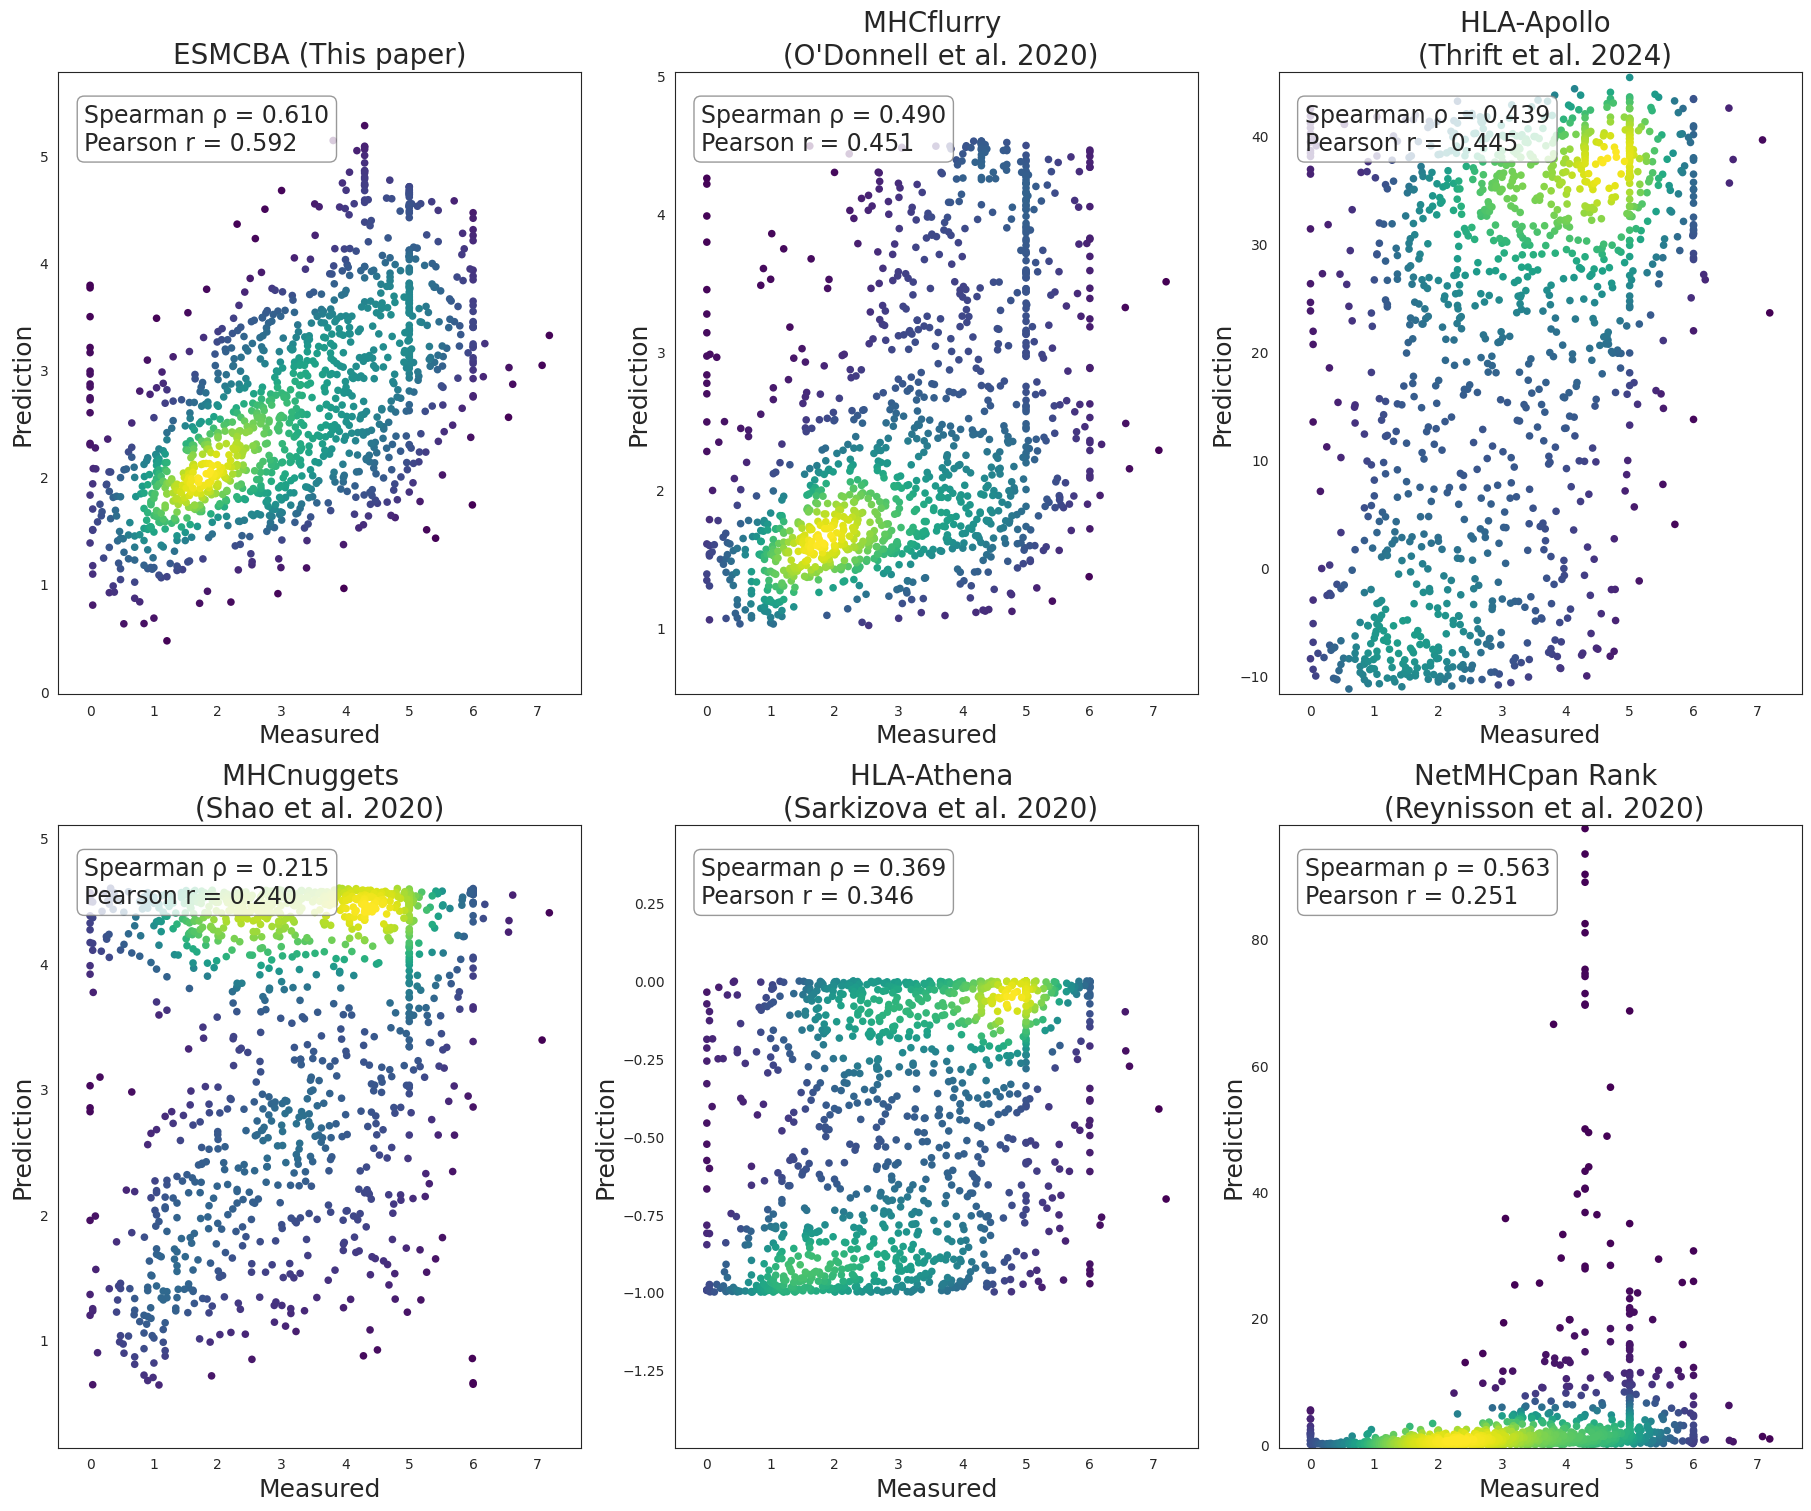

In [12]:
plot_pairs = [
    ('prediction', 'ESMCBA (This paper)'),
    ('mhc_log', "MHCflurry \n (O'Donnell et al. 2020)"),
    ('z_score_apollo', 'HLA-Apollo \n (Thrift et al. 2024)'),
    ('mhcnuggets_log', 'MHCnuggets  \n (Shao et al. 2020) '),
    ('best.MSi', 'HLA-Athena \n (Sarkizova et al. 2020)'),
    ('netmhc_log', 'NetMHCpan Rank \n (Reynisson et al. 2020)'),
    # ('mixmhc_rank', 'MixMHCpred (%Rank)'),
]


sns.set_style('white')

fig, axs = plt.subplots(2, 3, figsize=(18, 15), constrained_layout=True)
axs = axs.flatten()


for ax, (col, title) in zip(axs, plot_pairs):
    x = all_predictions['measured']
    y = all_predictions[col]

    # Drop NA
    valid = x.notna() & y.notna()
    x, y = x[valid], y[valid]

    # Density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

    # Plot
    sc = ax.scatter(x, y, c=z, cmap='viridis', s=30, edgecolor='none')
    spearman_rho, _ = spearmanr(x, y)
    pearson_r, _ = pearsonr(x, y)

    # Axis limits
    max_val = max(x.max(), y.max()) + 0.5
    ax.set_xlim(x.min()- 0.5, x.max() + 0.5)
    ax.set_ylim(y.min()- 0.5, y.max()+ 0.5)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Measured', fontsize=18)
    ax.set_ylabel('Prediction', fontsize=18)
    
    # Correlation text with background box
    text_str = f'Spearman ρ = {spearman_rho:.3f}\nPearson r = {pearson_r:.3f}'
    ax.text(
        0.05, 0.95, text_str,
        transform=ax.transAxes,
        fontsize=17,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    for j in range(len(plot_pairs), len(axs)):
        axs[j].axis('off')

# from pathlib import Path
# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(out_dir / "Scatterplot_models.pdf", dpi=300, bbox_inches="tight")
# plt.close(fig)

plt.show()


In [21]:
all_predictions.to_csv('../../data/01_predictions_models.csv', index= False)

In [13]:

training_data = pd.DataFrame()

for HLA in all_predictions['level_0'].unique():

    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{HLA}_final.csv"

    epitope_data = pd.read_csv(train_fasta, header = None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID','protein_origin', 'ID_SOURCE', "SOURCE_ORGANISM", "IC50_nM", "DESCRIPTION_BINDING", "Year_submission"]

    # Preprocess IC50 values (log10 transformation)
    epitope_data['IC50_nM'] = epitope_data['IC50_nM'].astype(str).replace('\\N', '0').astype(float) + 1
    epitope_data['IC50_nM'] = epitope_data['IC50_nM'].apply(np.log10)
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[["IC50_nM", "sequence", "Year_submission"]].values

    filtered_data = []

    for header, sequence, year_submission in epitope_data:
        if '+' in sequence:
            continue
        if '(' in sequence:
            continue
        if 'X' in sequence:
            continue
        # if 'epitope' not in encoding:   
            # sequence = hla_sequences + sequence
        else:
            sequence = sequence
            
        filtered_data.append((header, sequence, year_submission))

    max_length = np.max([len(x) for x in filtered_data])

    print(f"Filtered {len(filtered_data)} sequences for training.", flush=True)
    aggregated = pd.DataFrame(filtered_data, columns = ['label','sequence','testing'])
    aggregated['HLA'] = HLA
    training_data = pd.concat([ training_data, aggregated])


Filtered 4884 sequences for training.
Filtered 2293 sequences for training.
Filtered 2164 sequences for training.
Filtered 5833 sequences for training.
Filtered 945 sequences for training.
Filtered 2261 sequences for training.
Filtered 3341 sequences for training.
Filtered 3810 sequences for training.
Filtered 1360 sequences for training.
Filtered 122 sequences for training.
Filtered 169 sequences for training.
Filtered 3097 sequences for training.


Filtered 3925 sequences for training.
Filtered 3859 sequences for training.
Filtered 6511 sequences for training.
Filtered 16877 sequences for training.
Filtered 1823 sequences for training.
Filtered 2432 sequences for training.
Filtered 46 sequences for training.
Filtered 86 sequences for training.
Filtered 2620 sequences for training.
Filtered 2589 sequences for training.
Filtered 838 sequences for training.
Filtered 1666 sequences for training.
Filtered 24 sequences for training.


In [14]:
training_data[training_data['testing'] > 2019]['sequence'].unique()

array(['GRAKLLGAEEK', 'RAKLLGAEEK', 'HVKITDFGL', ..., 'SAFRCFIVY',
       'KRPTPTFHS', 'KRPTPTFHF'], dtype=object)

In [15]:
all_predictions_sub_new = pd.DataFrame()


for file in glob.glob("/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA*_final.csv"):

    if 'HLAD' in file:
        continue

    if os.stat(file).st_size == 0:
        continue

    epitope_data = pd.read_csv(file, sep=',', header = None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID','protein_origin', 'ID_SOURCE', "SOURCE_ORGANISM", "IC50_nM", "DESCRIPTION_BINDING", "Year_submission"]

    # Preprocess IC50 values (log10 transformation)
    epitope_data['IC50_nM'] = epitope_data['IC50_nM'].astype(str).replace('\\N', '0').astype(float) + 1
    epitope_data['IC50_nM'] = epitope_data['IC50_nM'].apply(np.log10)
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[["IC50_nM", "sequence", "Year_submission"]]

    # print(f'Before filter {all_predictions_sub.shape}')
    set1 = epitope_data[(epitope_data['Year_submission'] <= 2019)]['sequence'].unique()
    set2 = epitope_data[(epitope_data['Year_submission'] > 2019)]['sequence'].unique()

    if len(set(set1).intersection(set(set2))) > 10:
        print(file, len(set(set1).intersection(set(set2))))

    if 'A0201' in file:
        break

/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAHLAA0201_final.csv 21
